## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
import time
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

print("Libraries imported successfully")

Libraries imported successfully


## 2. Load Dataset

In [2]:
print("Loading data...")
data_path = './assets/mnist_merged_original+full+partial.npz'
data = np.load(data_path)

print(f"\nData loaded successfully!")
print(f"Data keys: {list(data.keys())}")
print()

for key in data.keys():
    print(f"[{key}]")
    print(f"  Shape: {data[key].shape}")
    print(f"  Dtype: {data[key].dtype}")
    print()

Loading data...

Data loaded successfully!
Data keys: ['train_images', 'digit_labels', 'fg_color_labels', 'bg_color_labels']

[train_images]
  Shape: (70000, 28, 28, 3)
  Dtype: uint8

[digit_labels]
  Shape: (70000,)
  Dtype: int64

[fg_color_labels]
  Shape: (70000,)
  Dtype: uint8

[bg_color_labels]
  Shape: (70000,)
  Dtype: uint8



## 3. Data Preprocessing

In [3]:
# Color definitions
RAINBOW_COLORS = [
    (255, 0, 0),    # Red
    (255, 127, 0),  # Orange
    (255, 255, 0),  # Yellow  
    (0, 255, 0),    # Green
    (0, 0, 255),    # Blue
    (75, 0, 130),   # Indigo
    (148, 0, 211)   # Violet
]

RAINBOW_NAMES = [
    'RED',
    'ORANGE',
    'YELLOW',
    'GREEN',
    'BLUE',
    'INDIGO',
    'VIOLET'
]

DIGIT_CLASSES = list(range(10))  # 0-9

print("Label definitions:")
print(f"  Digit classes: {DIGIT_CLASSES}")
print(f"  Color classes: {RAINBOW_NAMES}")
print(f"  Number of color classes: {len(RAINBOW_NAMES)}")


Label definitions:
  Digit classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
  Color classes: ['RED', 'ORANGE', 'YELLOW', 'GREEN', 'BLUE', 'INDIGO', 'VIOLET']
  Number of color classes: 7


In [4]:
train_images = data['train_images']
train_labels = data['digit_labels']
fg_labels = data['fg_color_labels']
bg_labels = data['bg_color_labels']

print(f"Data extraction completed")
print(f"  Images shape: {train_images.shape}")
print(f"  Digit labels shape: {train_labels.shape}")
print(f"  Foreground labels shape: {fg_labels.shape}")
print(f"  Background labels shape: {bg_labels.shape}")

Data extraction completed
  Images shape: (70000, 28, 28, 3)
  Digit labels shape: (70000,)
  Foreground labels shape: (70000,)
  Background labels shape: (70000,)


In [5]:
print("\nFlattening images...")
if len(train_images.shape) == 4:
    X_flat = train_images.reshape(train_images.shape[0], -1)
    print(f"  RGB images: {train_images.shape} -> {X_flat.shape}")
elif len(train_images.shape) == 3:
    X_flat = train_images.reshape(train_images.shape[0], -1)
    print(f"  Grayscale images: {train_images.shape} -> {X_flat.shape}")
else:
    X_flat = train_images
    print(f"  Already flattened: {X_flat.shape}")

X_normalized = X_flat / 255.0
print(f"Normalization completed (range: {X_normalized.min():.2f} ~ {X_normalized.max():.2f})")


Flattening images...
  RGB images: (70000, 28, 28, 3) -> (70000, 2352)
Normalization completed (range: 0.00 ~ 1.00)


## 4. Data Visualization

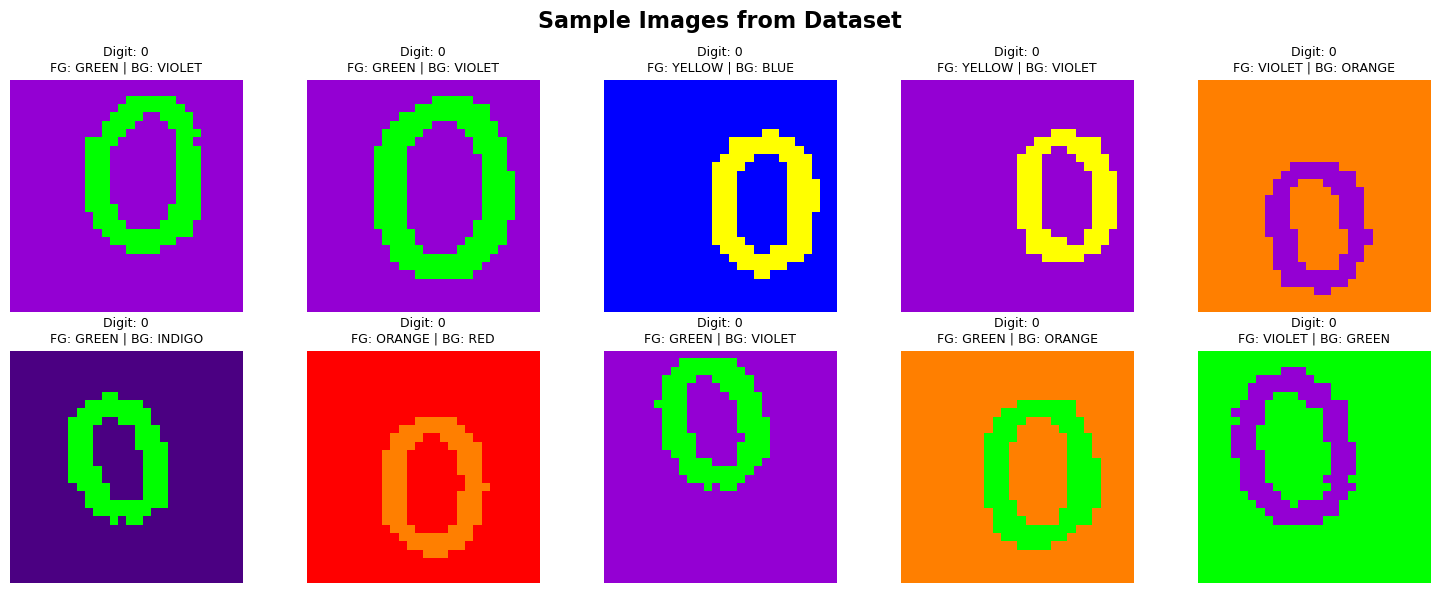

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Images from Dataset', fontsize=16, fontweight='bold')

for i, ax in enumerate(axes.flat):
    if i < len(train_images):
        img = train_images[i]
        
        if len(img.shape) == 3 and img.shape[2] == 3:
            ax.imshow(img)
        elif len(img.shape) == 2:
            ax.imshow(img, cmap='gray')
        else:
            ax.imshow(img.squeeze(), cmap='gray')
        
        title = f'Digit: {train_labels[i]}'
        if fg_labels is not None:
            fg_idx = int(fg_labels[i])
            fg_name = RAINBOW_NAMES[fg_idx] if fg_idx < len(RAINBOW_NAMES) else str(fg_idx)
            title += f'\nFG: {fg_name}'
        if bg_labels is not None:
            bg_idx = int(bg_labels[i])
            bg_name = RAINBOW_NAMES[bg_idx] if bg_idx < len(RAINBOW_NAMES) else str(bg_idx)
            title += f' | BG: {bg_name}'
        
        ax.set_title(title, fontsize=9)
        ax.axis('off')

plt.tight_layout()
plt.show()


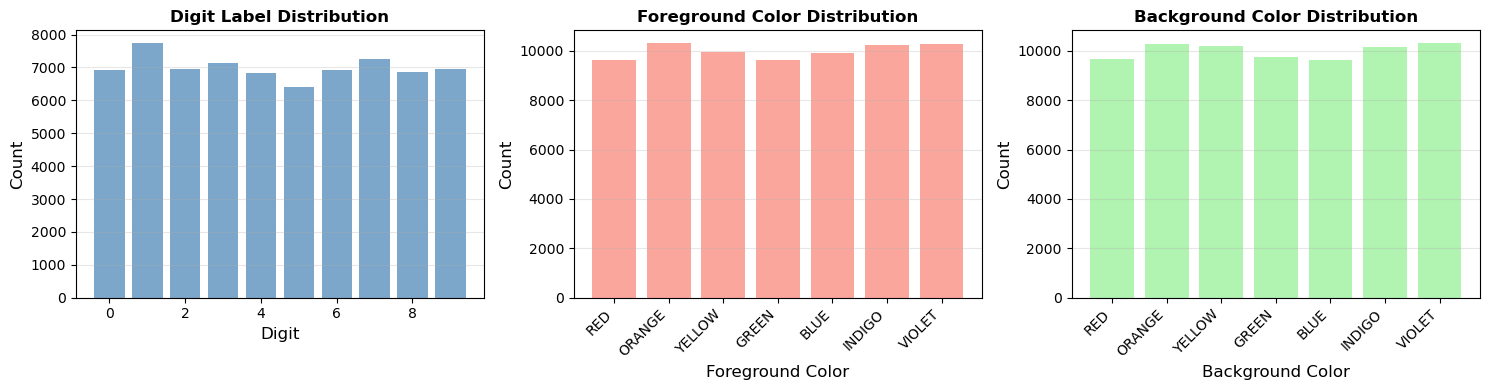

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax1 = axes[0]
unique, counts = np.unique(train_labels, return_counts=True)
ax1.bar(unique, counts, color='steelblue', alpha=0.7)
ax1.set_xlabel('Digit', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.set_title('Digit Label Distribution', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

if fg_labels is not None:
    ax2 = axes[1]
    unique, counts = np.unique(fg_labels, return_counts=True)
    ax2.bar(unique, counts, color='salmon', alpha=0.7)
    ax2.set_xlabel('Foreground Color', fontsize=12)
    ax2.set_ylabel('Count', fontsize=12)
    ax2.set_title('Foreground Color Distribution', fontsize=12, fontweight='bold')
    ax2.set_xticks(unique)
    ax2.set_xticklabels([RAINBOW_NAMES[int(i)] if int(i) < len(RAINBOW_NAMES) else str(i) for i in unique], rotation=45, ha='right')
    ax2.grid(axis='y', alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'No FG Labels', ha='center', va='center', 
                 transform=axes[1].transAxes, fontsize=14)
    axes[1].axis('off')

if bg_labels is not None:
    ax3 = axes[2]
    unique, counts = np.unique(bg_labels, return_counts=True)
    ax3.bar(unique, counts, color='lightgreen', alpha=0.7)
    ax3.set_xlabel('Background Color', fontsize=12)
    ax3.set_ylabel('Count', fontsize=12)
    ax3.set_title('Background Color Distribution', fontsize=12, fontweight='bold')
    ax3.set_xticks(unique)
    ax3.set_xticklabels([RAINBOW_NAMES[int(i)] if int(i) < len(RAINBOW_NAMES) else str(i) for i in unique], rotation=45, ha='right')
    ax3.grid(axis='y', alpha=0.3)
else:
    axes[2].text(0.5, 0.5, 'No BG Labels', ha='center', va='center', 
                 transform=axes[2].transAxes, fontsize=14)
    axes[2].axis('off')

plt.tight_layout()
plt.show()


## 5. Train/Test Split

In [8]:
test_size = 0.2
random_state = 42

print(f"Splitting data (Test size: {test_size*100}%)...")

X_train, X_test, y_digit_train, y_digit_test = train_test_split(
    X_normalized, train_labels, 
    test_size=test_size, 
    random_state=random_state, 
    stratify=train_labels
)

if fg_labels is not None:
    y_fg_train = fg_labels[y_digit_train.index] if hasattr(y_digit_train, 'index') else fg_labels[:len(y_digit_train)]
    y_fg_test = fg_labels[y_digit_test.index] if hasattr(y_digit_test, 'index') else fg_labels[len(y_digit_train):]
    
    _, _, y_fg_train, y_fg_test = train_test_split(
        X_normalized, fg_labels, 
        test_size=test_size, 
        random_state=random_state, 
        stratify=train_labels
    )
else:
    y_fg_train = y_fg_test = None

if bg_labels is not None:
    _, _, y_bg_train, y_bg_test = train_test_split(
        X_normalized, bg_labels, 
        test_size=test_size, 
        random_state=random_state, 
        stratify=train_labels
    )
else:
    y_bg_train = y_bg_test = None

print(f"Split completed")
print(f"  Train: {X_train.shape[0]:,} samples")
print(f"  Test:  {X_test.shape[0]:,} samples")
print(f"  Features: {X_train.shape[1]:,}")


Splitting data (Test size: 20.0%)...
Split completed
  Train: 56,000 samples
  Test:  14,000 samples
  Features: 2,352


## 7. Model Definition


In [9]:
def get_models():
    """Return a fresh set of models for each training task"""
    return {
        'Decision Tree': DecisionTreeClassifier(
            max_depth=20, 
            random_state=42
        ),
        'K-Nearest Neighbors': KNeighborsClassifier(
            n_neighbors=5, 
            n_jobs=1
        ),
        'Logistic Regression': LogisticRegression(
            max_iter=100, 
            random_state=42, 
            n_jobs=1,
            solver='saga'
        ),
        'SVM (Linear)': SVC(
            kernel='linear', 
            random_state=42, 
            max_iter=100
        ),
        'SVM (RBF)': SVC(
            kernel='rbf', 
            random_state=42, 
            max_iter=100,
            gamma='scale'
        )
    }

print("Model definition completed")
print(f"Number of models: {len(get_models())}")
for name in get_models().keys():
    print(f"  - {name}")

Model definition completed
Number of models: 5
  - Decision Tree
  - K-Nearest Neighbors
  - Logistic Regression
  - SVM (Linear)
  - SVM (RBF)


## 8. Model Training and Evaluation


In [10]:
def train_and_evaluate(models, X_train, X_test, y_train, y_test, task_name='Classification'):
    print(f"\n{'='*70}")
    print(f"{task_name}")
    print(f"{'='*70}\n")
    
    # Debug: Check models parameter
    print(f"[DEBUG] Received {len(models)} models to train")
    print(f"[DEBUG] Model names: {list(models.keys())}\n")
    
    results = []
    
    for idx, (name, model) in enumerate(models.items(), 1):
        print(f"[{idx}/{len(models)}] Training {name}...")
        start_time = time.time()
        
        try:
            model.fit(X_train, y_train)
            
            y_pred = model.predict(X_test)
            
            accuracy = accuracy_score(y_test, y_pred)
            
            elapsed = time.time() - start_time
            
            print(f"  Completed - Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%) | Time: {elapsed:.2f}s\n")
            
            results.append({
                'Model': name,
                'Accuracy': accuracy,
                'Accuracy (%)': accuracy * 100,
                'Time (s)': elapsed
            })
            
        except Exception as e:
            print(f"  Error occurred: {e}\n")
            results.append({
                'Model': name,
                'Accuracy': 0,
                'Accuracy (%)': 0,
                'Time (s)': 0
            })
    
    print(f"[DEBUG] Training completed. Generated {len(results)} results.\n")
    
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
    
    return results_df


## 9. Task 1: Digit Classification


In [11]:
# Debug: Check model count before training
models_dict = get_models()
print(f"Number of models to train: {len(models_dict)}")
print(f"Model names: {list(models_dict.keys())}")
print()

digit_results = train_and_evaluate(
    models_dict, 
    X_train, 
    X_test, 
    y_digit_train, 
    y_digit_test,
    task_name='Digit Classification'
)

print("\nDigit Classification Results:")
print(digit_results.to_string(index=False))
print()


Number of models to train: 5
Model names: ['Decision Tree', 'K-Nearest Neighbors', 'Logistic Regression', 'SVM (Linear)', 'SVM (RBF)']


Digit Classification

[DEBUG] Received 5 models to train
[DEBUG] Model names: ['Decision Tree', 'K-Nearest Neighbors', 'Logistic Regression', 'SVM (Linear)', 'SVM (RBF)']

[1/5] Training Decision Tree...
  Completed - Accuracy: 0.4015 (40.15%) | Time: 29.16s

[2/5] Training K-Nearest Neighbors...
  Completed - Accuracy: 0.8420 (84.20%) | Time: 9.32s

[3/5] Training Logistic Regression...
  Completed - Accuracy: 0.1761 (17.61%) | Time: 787.59s

[4/5] Training SVM (Linear)...
  Completed - Accuracy: 0.1196 (11.96%) | Time: 244.64s

[5/5] Training SVM (RBF)...
  Completed - Accuracy: 0.1134 (11.34%) | Time: 300.65s

[DEBUG] Training completed. Generated 5 results.


Digit Classification Results:
              Model  Accuracy  Accuracy (%)   Time (s)
K-Nearest Neighbors  0.842000     84.200000   9.316227
      Decision Tree  0.401500     40.150000  29.158

## 10. Task 2: Foreground Color Classification


In [12]:
if y_fg_train is not None and y_fg_test is not None:
    fg_results = train_and_evaluate(
        get_models(), 
        X_train, 
        X_test, 
        y_fg_train, 
        y_fg_test,
        task_name='Foreground Color Classification'
    )
    
    print("\nForeground Color Classification Results:")
    print(fg_results.to_string(index=False))
    print()
else:
    print("\nNo foreground labels available. Skipping this task.")
    fg_results = None



Foreground Color Classification

[DEBUG] Received 5 models to train
[DEBUG] Model names: ['Decision Tree', 'K-Nearest Neighbors', 'Logistic Regression', 'SVM (Linear)', 'SVM (RBF)']

[1/5] Training Decision Tree...
  Completed - Accuracy: 0.9366 (93.66%) | Time: 11.14s

[2/5] Training K-Nearest Neighbors...
  Completed - Accuracy: 0.7889 (78.89%) | Time: 8.33s

[3/5] Training Logistic Regression...
  Completed - Accuracy: 0.9726 (97.26%) | Time: 569.93s

[4/5] Training SVM (Linear)...
  Completed - Accuracy: 0.5990 (59.90%) | Time: 95.72s

[5/5] Training SVM (RBF)...
  Completed - Accuracy: 0.6830 (68.30%) | Time: 149.06s

[DEBUG] Training completed. Generated 5 results.


Foreground Color Classification Results:
              Model  Accuracy  Accuracy (%)   Time (s)
Logistic Regression  0.972571     97.257143 569.929515
      Decision Tree  0.936571     93.657143  11.136870
K-Nearest Neighbors  0.788929     78.892857   8.332108
          SVM (RBF)  0.683000     68.300000 149.060970
 

## 11. Task 3: Background Color Classification


In [13]:
if y_bg_train is not None and y_bg_test is not None:
    bg_results = train_and_evaluate(
        get_models(), 
        X_train, 
        X_test, 
        y_bg_train, 
        y_bg_test,
        task_name='Background Color Classification'
    )
    
    print("\nBackground Color Classification Results:")
    print(bg_results.to_string(index=False))
    print()
else:
    print("\nNo background labels available. Skipping this task.")
    bg_results = None



Background Color Classification

[DEBUG] Received 5 models to train
[DEBUG] Model names: ['Decision Tree', 'K-Nearest Neighbors', 'Logistic Regression', 'SVM (Linear)', 'SVM (RBF)']

[1/5] Training Decision Tree...
  Completed - Accuracy: 0.9999 (99.99%) | Time: 5.26s

[2/5] Training K-Nearest Neighbors...
  Completed - Accuracy: 0.9999 (99.99%) | Time: 8.35s

[3/5] Training Logistic Regression...
  Completed - Accuracy: 0.9999 (99.99%) | Time: 571.19s

[4/5] Training SVM (Linear)...
  Completed - Accuracy: 1.0000 (100.00%) | Time: 27.07s

[5/5] Training SVM (RBF)...
  Completed - Accuracy: 1.0000 (100.00%) | Time: 61.71s

[DEBUG] Training completed. Generated 5 results.


Background Color Classification Results:
              Model  Accuracy  Accuracy (%)   Time (s)
          SVM (RBF)  1.000000    100.000000  61.708603
       SVM (Linear)  1.000000    100.000000  27.071970
      Decision Tree  0.999929     99.992857   5.259630
K-Nearest Neighbors  0.999929     99.992857   8.354978
L

## 12. Model Performance Comparison


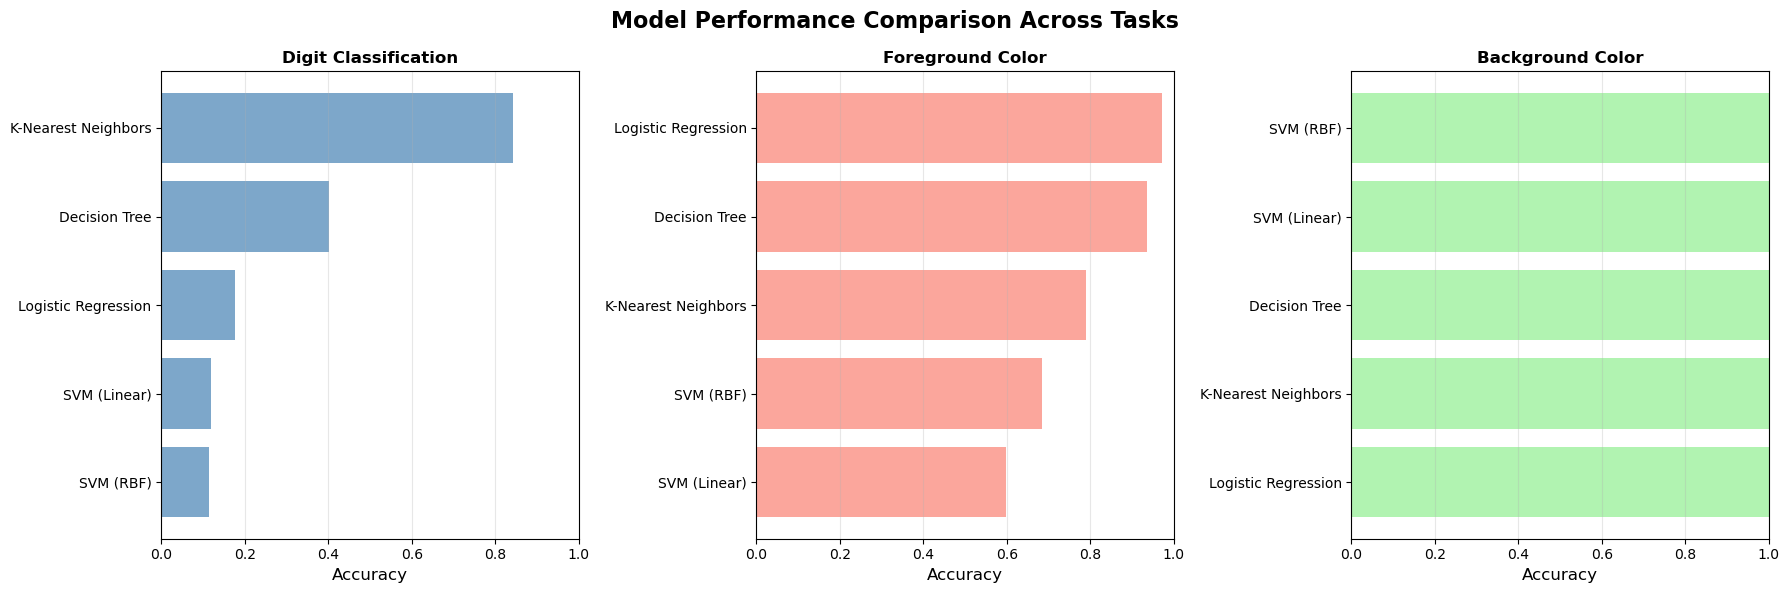

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Model Performance Comparison Across Tasks', fontsize=16, fontweight='bold')

ax1 = axes[0]
digit_results_sorted = digit_results.sort_values('Accuracy')
ax1.barh(digit_results_sorted['Model'], digit_results_sorted['Accuracy'], color='steelblue', alpha=0.7)
ax1.set_xlabel('Accuracy', fontsize=12)
ax1.set_title('Digit Classification', fontsize=12, fontweight='bold')
ax1.set_xlim(0, 1.0)
ax1.grid(axis='x', alpha=0.3)

ax2 = axes[1]
if fg_results is not None:
    fg_results_sorted = fg_results.sort_values('Accuracy')
    ax2.barh(fg_results_sorted['Model'], fg_results_sorted['Accuracy'], color='salmon', alpha=0.7)
    ax2.set_xlabel('Accuracy', fontsize=12)
    ax2.set_title('Foreground Color', fontsize=12, fontweight='bold')
    ax2.set_xlim(0, 1.0)
    ax2.grid(axis='x', alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'No FG Labels', ha='center', va='center', 
             transform=ax2.transAxes, fontsize=14)
    ax2.set_title('Foreground Color', fontsize=12, fontweight='bold')

ax3 = axes[2]
if bg_results is not None:
    bg_results_sorted = bg_results.sort_values('Accuracy')
    ax3.barh(bg_results_sorted['Model'], bg_results_sorted['Accuracy'], color='lightgreen', alpha=0.7)
    ax3.set_xlabel('Accuracy', fontsize=12)
    ax3.set_title('Background Color', fontsize=12, fontweight='bold')
    ax3.set_xlim(0, 1.0)
    ax3.grid(axis='x', alpha=0.3)
else:
    ax3.text(0.5, 0.5, 'No BG Labels', ha='center', va='center', 
             transform=ax3.transAxes, fontsize=14)
    ax3.set_title('Background Color', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


## 13. Best Model Selection and Detailed Analysis


In [15]:
print("\n" + "="*70)
print("Best Performing Models")
print("="*70)

best_digit_model_name = digit_results.iloc[0]['Model']
best_digit_accuracy = digit_results.iloc[0]['Accuracy']
print(f"\n1. Digit Classification: {best_digit_model_name} - {best_digit_accuracy:.4f} ({best_digit_accuracy*100:.2f}%)")

if fg_results is not None:
    best_fg_model_name = fg_results.iloc[0]['Model']
    best_fg_accuracy = fg_results.iloc[0]['Accuracy']
    print(f"2. Foreground Color: {best_fg_model_name} - {best_fg_accuracy:.4f} ({best_fg_accuracy*100:.2f}%)")

if bg_results is not None:
    best_bg_model_name = bg_results.iloc[0]['Model']
    best_bg_accuracy = bg_results.iloc[0]['Accuracy']
    print(f"3. Background Color: {best_bg_model_name} - {best_bg_accuracy:.4f} ({best_bg_accuracy*100:.2f}%)")

print("="*70)



Best Performing Models

1. Digit Classification: K-Nearest Neighbors - 0.8420 (84.20%)
2. Foreground Color: Logistic Regression - 0.9726 (97.26%)
3. Background Color: SVM (RBF) - 1.0000 (100.00%)



Detailed Analysis of Best Model

K-Nearest Neighbors - Digit Classification

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.94      0.91      1385
           1       0.66      0.98      0.79      1548
           2       0.93      0.81      0.86      1392
           3       0.83      0.82      0.83      1426
           4       0.90      0.81      0.85      1368
           5       0.88      0.79      0.83      1284
           6       0.91      0.90      0.91      1384
           7       0.84      0.86      0.85      1453
           8       0.93      0.70      0.80      1370
           9       0.81      0.81      0.81      1390

    accuracy                           0.84     14000
   macro avg       0.86      0.84      0.84     14000
weighted avg       0.86      0.84      0.84     14000



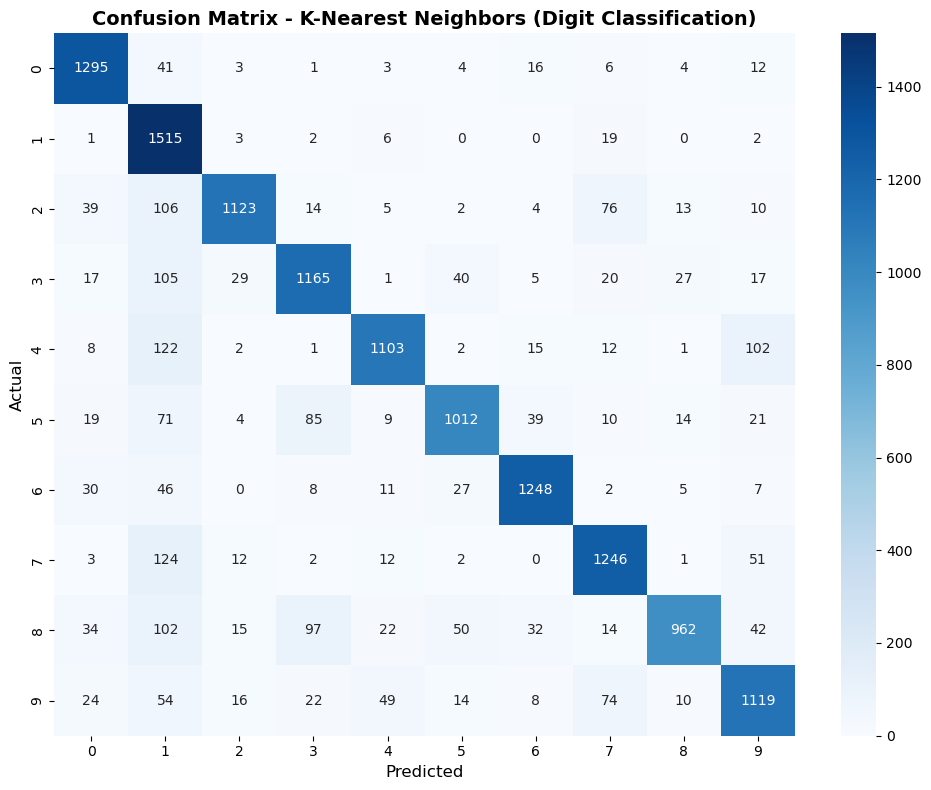

In [16]:
print("\nDetailed Analysis of Best Model\n")

best_digit_model = get_models()[best_digit_model_name]
best_digit_model.fit(X_train, y_digit_train)
y_digit_pred = best_digit_model.predict(X_test)

print(f"{best_digit_model_name} - Digit Classification")
print("\nClassification Report:")
print(classification_report(y_digit_test, y_digit_pred))

cm = confusion_matrix(y_digit_test, y_digit_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title(f'Confusion Matrix - {best_digit_model_name} (Digit Classification)', 
          fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()


## 14. Training Time vs Accuracy Analysis


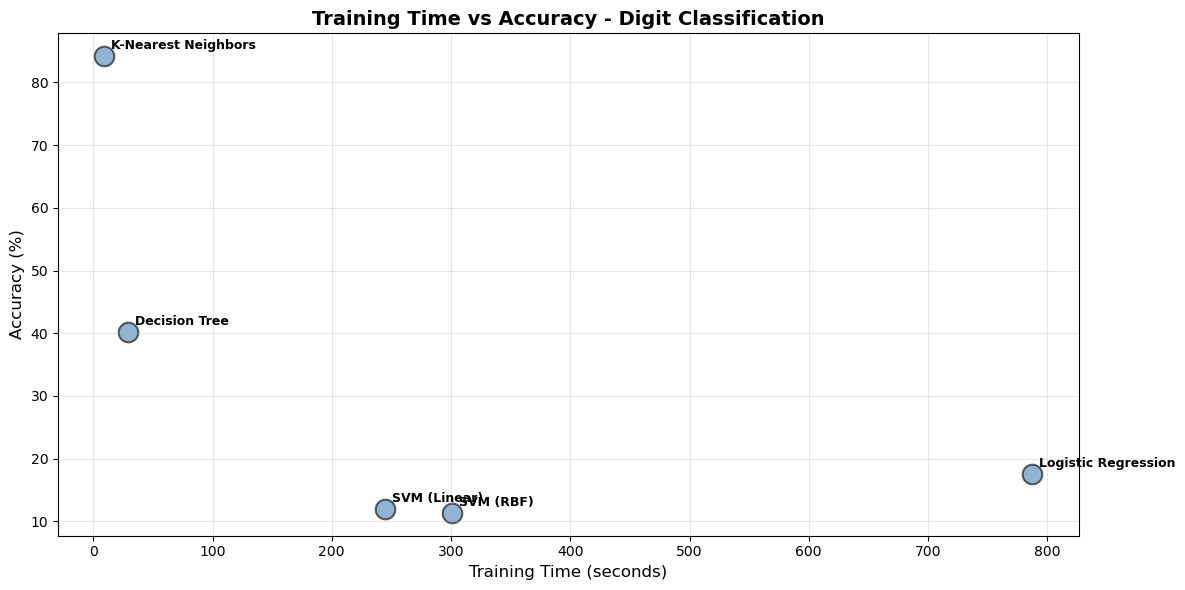


Interpretation:
  - Top left: Fast and accurate models (ideal)
  - Top right: Slow but accurate models
  - Bottom left: Fast but inaccurate models
  - Bottom right: Slow and inaccurate models (worst)


In [17]:
plt.figure(figsize=(12, 6))

plt.scatter(digit_results['Time (s)'], digit_results['Accuracy (%)'], 
           s=200, alpha=0.6, c='steelblue', edgecolors='black', linewidths=1.5)

for i, row in digit_results.iterrows():
    plt.annotate(row['Model'], 
                (row['Time (s)'], row['Accuracy (%)']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=9, fontweight='bold')

plt.xlabel('Training Time (seconds)', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Training Time vs Accuracy - Digit Classification', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("  - Top left: Fast and accurate models (ideal)")
print("  - Top right: Slow but accurate models")
print("  - Bottom left: Fast but inaccurate models")
print("  - Bottom right: Slow and inaccurate models (worst)")


## 15. Summary and Conclusion


In [19]:
USE = False

print("\n" + "="*70)
print("Experiment Summary")
print("="*70)

print(f"\nDataset: mnist_merged_original+full+partial.npz")
print(f"  - Total samples: {len(train_labels):,}")
print(f"  - Train samples: {len(y_digit_train):,}")
print(f"  - Test samples: {len(y_digit_test):,}")
print(f"  - Feature dimensions: {X_train.shape[1]:,}")
print(f"  - HOG used: {'Yes' if USE else 'No'}")

print(f"\nNumber of models tested: {len(get_models())}")

print(f"\nBest performance per task:")
print(f"  1. Digit Classification: {best_digit_model_name} ({best_digit_accuracy*100:.2f}%)")
if fg_results is not None:
    print(f"  2. Foreground Color: {best_fg_model_name} ({best_fg_accuracy*100:.2f}%)")
if bg_results is not None:
    print(f"  3. Background Color: {best_bg_model_name} ({best_bg_accuracy*100:.2f}%)")

print("\nConclusions:")
print("  - Compared various machine learning models")
print("  - Optimal model may differ for each task")
print("  - Consider accuracy vs training time tradeoff when selecting models")
print("  - HOG features may improve performance (set USE=True)")

print("\n" + "="*70)
print("Experiment completed!")
print("="*70)



Experiment Summary

Dataset: mnist_merged_original+full+partial.npz
  - Total samples: 70,000
  - Train samples: 56,000
  - Test samples: 14,000
  - Feature dimensions: 2,352
  - HOG used: No

Number of models tested: 5

Best performance per task:
  1. Digit Classification: K-Nearest Neighbors (84.20%)
  2. Foreground Color: Logistic Regression (97.26%)
  3. Background Color: SVM (RBF) (100.00%)

Conclusions:
  - Compared various machine learning models
  - Optimal model may differ for each task
  - Consider accuracy vs training time tradeoff when selecting models
  - HOG features may improve performance (set USE=True)

Experiment completed!
